<a href="https://colab.research.google.com/github/DebopriyoKarmakar/Smartphone-Sentiment-Pain-Point-Intelligence/blob/main/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Load & Inspect dataset
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Mobile Reviews Sentiment.csv")
print(df.shape)
print(df.columns.tolist())
print(df['brand'].value_counts())
print(df['sentiment'].value_counts())
print(df['country'].value_counts())

(50000, 25)
['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'review_text', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'review_length', 'word_count', 'helpful_votes', 'source']
brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64
sentiment
Positive    27540
Neutral     12549
Negative     9911
Name: count, dtype: int64
country
USA          6435
Brazil       6419
UAE          6261
Australia    6219
UK           6210
Canada       6170
Germany      6162
India        6124
Name: count, dtype: int64


In [2]:
#Install & Run VADER Sentiment
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['vader_compound'] = df['review_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

df['vader_sentiment'] = df['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)

# Compare VADER vs pre-existing labels
print(pd.crosstab(df['sentiment'], df['vader_sentiment']))
agreement = (df['sentiment'] == df['vader_sentiment']).mean() * 100
print(f"Agreement rate: {agreement:.1f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.1 MB/s eta 0:00:00
vader_sentiment  Negative  Neutral  Positive
sentiment                                   
Negative             6456     2256      1199
Neutral              2554      843      9152
Positive                0        0     27540
Agreement rate: 69.7%


In [3]:
#Pain Point Categorization
pain_categories = {
    'Battery': ['battery', 'charging', 'charge', 'drain', 'battery life', 'power'],
    'Camera': ['camera', 'photo', 'picture', 'lens', 'selfie', 'blur', 'image'],
    'Heating': ['heat', 'heating', 'hot', 'overheat', 'warm'],
    'Performance': ['slow', 'lag', 'hang', 'crash', 'freeze', 'speed', 'performance'],
    'Display': ['screen', 'display', 'brightness', 'touch', 'crack', 'scratch'],
    'Software': ['update', 'bug', 'software', 'ui', 'ads', 'bloatware', 'app']
}

for category, keywords in pain_categories.items():
    df[f'pain_{category}'] = df['review_text'].str.lower().apply(
        lambda x: any(kw in str(x) for kw in keywords)
    )

# Pain point distribution (negative reviews only)
neg_df = df[df['sentiment'] == 'Negative']
pain_counts = {}
for category in pain_categories:
    pain_counts[category] = neg_df[f'pain_{category}'].sum()

pain_series = pd.Series(pain_counts).sort_values(ascending=False)
print("\nPain Point Distribution:")
for cat, count in pain_series.items():
    pct = count / len(neg_df) * 100
    print(f"  {cat}: {count} ({pct:.1f}%)")


Pain Point Distribution:
  Software: 4850 (48.9%)
  Performance: 2960 (29.9%)
  Battery: 1907 (19.2%)
  Heating: 1048 (10.6%)
  Camera: 975 (9.8%)
  Display: 945 (9.5%)


In [4]:
# TF IDF Pain Point Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

negative_reviews = df[df['sentiment'] == 'Negative']['review_text'].dropna()

tfidf = TfidfVectorizer(max_features=100, stop_words='english',
                         ngram_range=(1, 2), min_df=5)
tfidf_matrix = tfidf.fit_transform(negative_reviews)

feature_names = tfidf.get_feature_names_out()
mean_scores = tfidf_matrix.mean(axis=0).A1
top_terms = pd.Series(mean_scores, index=feature_names).sort_values(ascending=False)
print("Top 20 Pain Point Terms:")
print(top_terms.head(20))

Top 20 Pain Point Terms:
disappointed             0.063509
mark                     0.062987
wouldn                   0.060291
wouldn recommend         0.060291
recommend                0.060291
returning                0.059598
returning soon           0.059598
soon                     0.059598
phone                    0.055022
quality                  0.052391
quickly                  0.037178
overheats quickly        0.037178
gaming                   0.037178
overheats                0.037178
quickly gaming           0.037178
service                  0.036968
service disappointing    0.036968
customer service         0.036968
disappointing            0.036968
customer                 0.036968
dtype: float64


In [5]:
# Brand vs Brand Comparison
brand_sentiment = df.groupby('brand').agg(
    avg_rating=('rating', 'mean'),
    avg_vader=('vader_compound', 'mean'),
    pct_positive=('sentiment', lambda x: (x == 'Positive').mean() * 100),
    pct_negative=('sentiment', lambda x: (x == 'Negative').mean() * 100),
    review_count=('review_id', 'count'),
    avg_battery=('battery_life_rating', 'mean'),
    avg_camera=('camera_rating', 'mean'),
    avg_performance=('performance_rating', 'mean'),
    avg_design=('design_rating', 'mean'),
    avg_display=('display_rating', 'mean')
).round(2)

print(brand_sentiment.to_string())

          avg_rating  avg_vader  pct_positive  pct_negative  review_count  avg_battery  avg_camera  avg_performance  avg_design  avg_display
brand                                                                                                                                       
Apple           3.13       0.41         55.28         20.03          7144         2.72        2.74             2.72        2.73         2.72
Google          3.12       0.41         55.28         19.12          7234         2.72        2.72             2.70        2.72         2.73
Motorola        3.11       0.41         54.21         19.50          7061         2.70        2.70             2.72        2.71         2.72
OnePlus         3.13       0.41         55.48         20.10          7136         2.72        2.73             2.72        2.70         2.72
Realme          3.14       0.42         55.71         19.83          7132         2.73        2.72             2.75        2.72         2.75
Samsung      

In [6]:
# Pain Points by Brand
target_brands = ['Samsung', 'Xiaomi', 'Realme', 'OnePlus', 'Motorola']

print("\nPain Points by Brand (% of negative reviews):")
for brand in target_brands:
    brand_neg = neg_df[neg_df['brand'] == brand]
    print(f"\n  {brand} ({len(brand_neg)} negative reviews):")
    for category in pain_categories:
        pct = brand_neg[f'pain_{category}'].mean() * 100
        print(f"    {category}: {pct:.1f}%")


Pain Points by Brand (% of negative reviews):

  Samsung (1402 negative reviews):
    Battery: 18.9%
    Camera: 9.8%
    Heating: 13.1%
    Performance: 26.7%
    Display: 9.1%
    Software: 51.4%

  Xiaomi (1470 negative reviews):
    Battery: 20.0%
    Camera: 8.2%
    Heating: 11.3%
    Performance: 30.1%
    Display: 9.3%
    Software: 50.7%

  Realme (1414 negative reviews):
    Battery: 18.5%
    Camera: 9.9%
    Heating: 8.4%
    Performance: 30.6%
    Display: 10.3%
    Software: 47.9%

  OnePlus (1434 negative reviews):
    Battery: 19.7%
    Camera: 10.1%
    Heating: 8.9%
    Performance: 30.3%
    Display: 9.3%
    Software: 48.2%

  Motorola (1377 negative reviews):
    Battery: 19.7%
    Camera: 9.7%
    Heating: 10.0%
    Performance: 31.6%
    Display: 9.4%
    Software: 46.5%


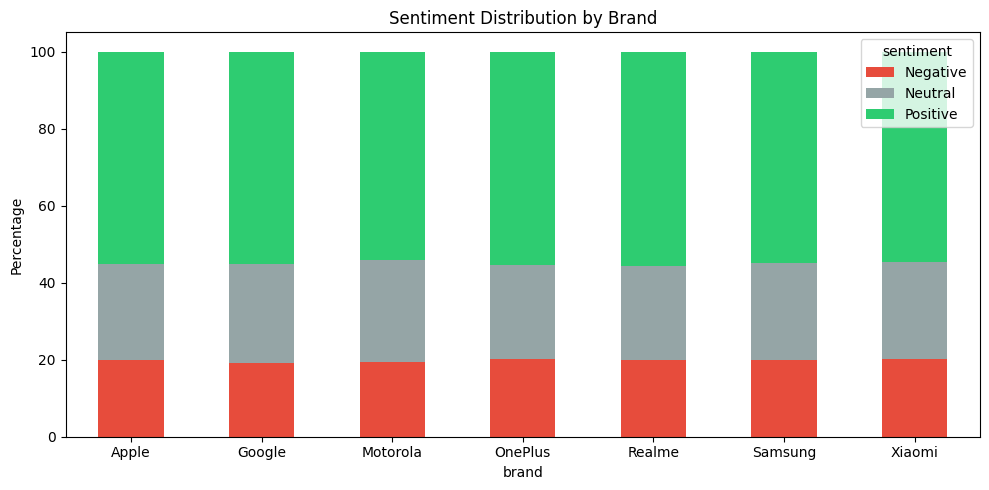

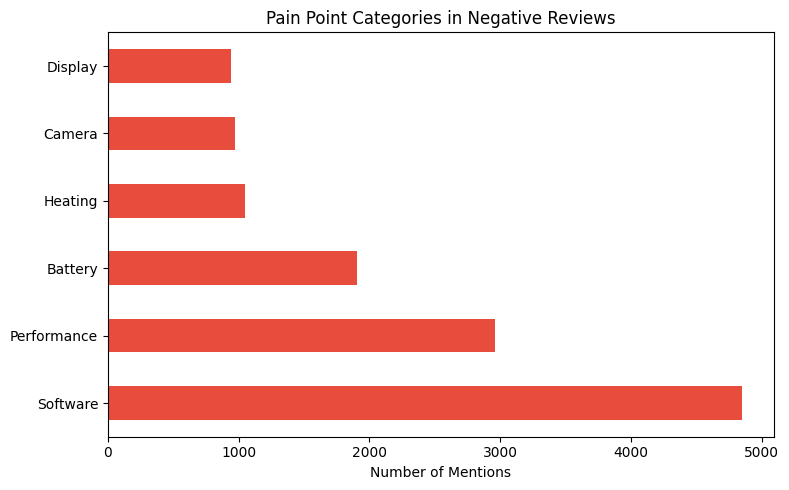

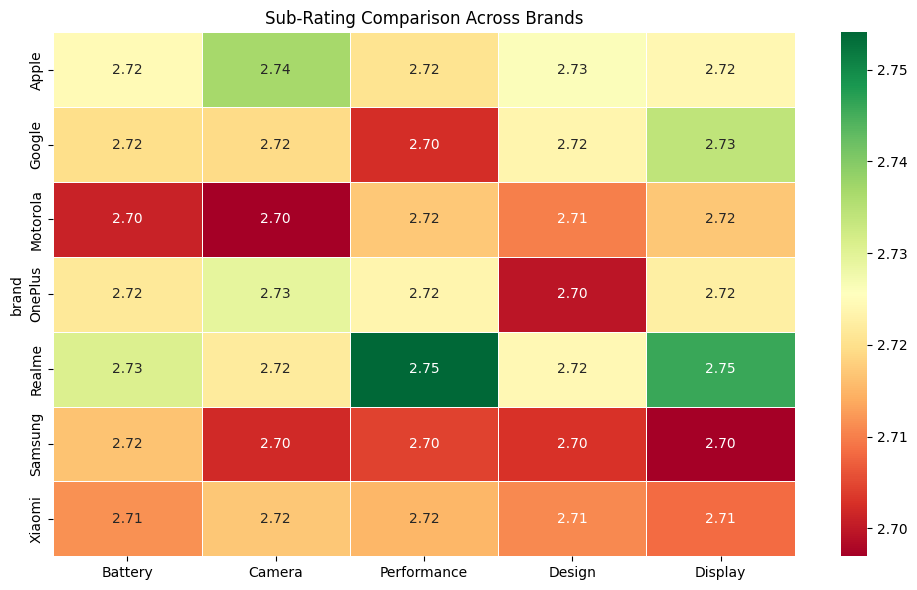

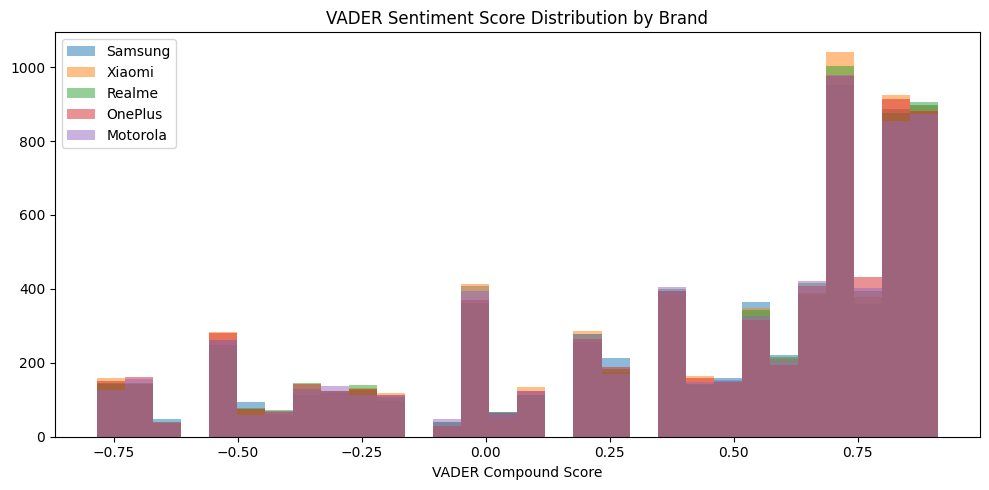

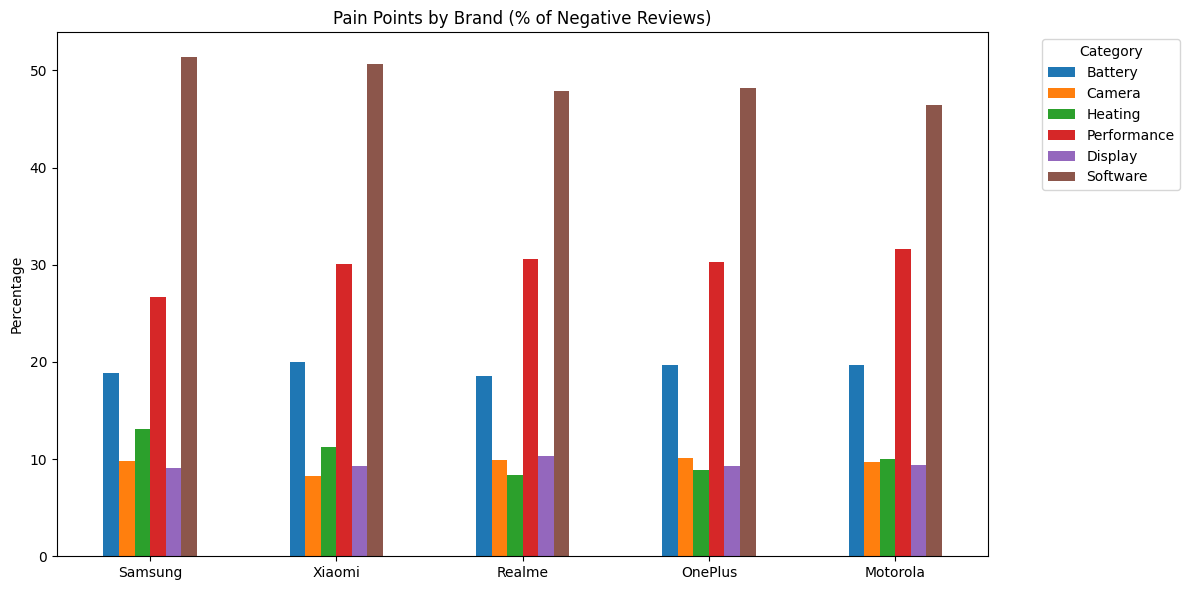

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# Chart 1: Sentiment by Brand
fig, ax = plt.subplots(figsize=(10, 5))
sentiment_pct = df.groupby(['brand', 'sentiment']).size().unstack(fill_value=0)
sentiment_pct = sentiment_pct.div(sentiment_pct.sum(axis=1), axis=0) * 100
sentiment_pct.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution by Brand')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_by_brand.png')
plt.show()

# Chart 2: Pain Point Distribution
fig, ax = plt.subplots(figsize=(8, 5))
pain_series.plot(kind='barh', color='#e74c3c', ax=ax)
plt.title('Pain Point Categories in Negative Reviews')
plt.xlabel('Number of Mentions')
plt.tight_layout()
plt.savefig('pain_point_distribution.png')
plt.show()

# Chart 3: Sub-Rating Heatmap
sub_ratings = df.groupby('brand')[['battery_life_rating', 'camera_rating',
    'performance_rating', 'design_rating', 'display_rating']].mean()
sub_ratings.columns = ['Battery', 'Camera', 'Performance', 'Design', 'Display']
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(sub_ratings, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5, ax=ax)
plt.title('Sub-Rating Comparison Across Brands')
plt.tight_layout()
plt.savefig('sub_rating_heatmap.png')
plt.show()

# Chart 4: VADER Distribution by Brand
fig, ax = plt.subplots(figsize=(10, 5))
for brand in target_brands:
    brand_data = df[df['brand'] == brand]['vader_compound']
    ax.hist(brand_data, bins=30, alpha=0.5, label=brand)
plt.title('VADER Sentiment Score Distribution by Brand')
plt.xlabel('VADER Compound Score')
plt.legend()
plt.tight_layout()
plt.savefig('vader_distribution.png')
plt.show()

# Chart 5: Pain Points by Brand Grouped Bar
brand_pain = pd.DataFrame()
for brand in target_brands:
    brand_neg = neg_df[neg_df['brand'] == brand]
    row = {}
    for cat in pain_categories:
        row[cat] = brand_neg[f'pain_{cat}'].mean() * 100
    brand_pain[brand] = pd.Series(row)
fig, ax = plt.subplots(figsize=(12, 6))
brand_pain.T.plot(kind='bar', ax=ax)
plt.title('Pain Points by Brand (% of Negative Reviews)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('pain_by_brand.png')
plt.show()

In [8]:
!pip install mysql-connector-python

import mysql.connector

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='YOUR_PASSWORD',  # ← change this
    database='smartphone_sentiment'  # create this DB first in MySQL Workbench
)
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS reviews (
    review_id INT PRIMARY KEY,
    brand VARCHAR(50),
    model VARCHAR(100),
    price_usd DECIMAL(10,2),
    rating INT,
    review_text TEXT,
    sentiment VARCHAR(20),
    vader_compound DECIMAL(5,4),
    vader_sentiment VARCHAR(20),
    country VARCHAR(50),
    review_date DATE,
    source VARCHAR(50),
    battery_life_rating INT,
    camera_rating INT,
    performance_rating INT,
    design_rating INT,
    display_rating INT
)
""")

# Insert all rows
for _, row in df.iterrows():
    cursor.execute("""
        INSERT IGNORE INTO reviews VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """, (
        int(row['review_id']), row['brand'], row['model'],
        float(row['price_usd']), int(row['rating']), str(row['review_text']),
        row['sentiment'], float(row['vader_compound']), row['vader_sentiment'],
        row['country'], row['review_date'], row['source'],
        int(row['battery_life_rating']), int(row['camera_rating']),
        int(row['performance_rating']), int(row['design_rating']),
        int(row['display_rating'])
    ))

conn.commit()
print(f"Inserted {len(df)} rows")

# Create pain_points table
cursor.execute("""
CREATE TABLE IF NOT EXISTS pain_points (
    review_id INT,
    category VARCHAR(50),
    FOREIGN KEY (review_id) REFERENCES reviews(review_id)
)
""")

for _, row in neg_df.iterrows():
    for category in pain_categories:
        if row[f'pain_{category}']:
            cursor.execute(
                "INSERT INTO pain_points VALUES (%s, %s)",
                (int(row['review_id']), category)
            )
conn.commit()
print("Pain points table done")
cursor.close()
conn.close()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 72.0 MB/s eta 0:00:00


InterfaceError: 2003: Can't connect to MySQL server on 'localhost:3306' (Errno 111: Connection refused)

In [9]:
export_cols = ['review_id', 'brand', 'model', 'price_usd', 'rating',
               'review_text', 'sentiment', 'vader_compound', 'vader_sentiment',
               'country', 'review_date', 'source',
               'battery_life_rating', 'camera_rating', 'performance_rating',
               'design_rating', 'display_rating']

df[export_cols].to_csv('reviews_for_mysql.csv', index=False, na_rep='')

from google.colab import files
files.download('reviews_for_mysql.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Build pain_points dataframe
pain_rows = []
for _, row in neg_df.iterrows():
    for category in pain_categories:
        if row[f'pain_{category}']:
            pain_rows.append({'review_id': int(row['review_id']), 'category': category})

pain_df = pd.DataFrame(pain_rows)
pain_df.to_csv('pain_points_for_mysql.csv', index=False)
files.download('pain_points_for_mysql.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files

# CSV 1: Full review data
export_cols = ['review_id', 'brand', 'model', 'price_usd', 'rating',
               'review_text', 'sentiment', 'vader_compound', 'vader_sentiment',
               'country', 'review_date', 'source',
               'battery_life_rating', 'camera_rating', 'performance_rating',
               'design_rating', 'display_rating']
df[export_cols].to_csv('reviews_for_powerbi.csv', index=False)
files.download('reviews_for_powerbi.csv')

# CSV 2: Brand sentiment summary
brand_sentiment.to_csv('brand_sentiment_summary.csv')
files.download('brand_sentiment_summary.csv')

# CSV 3: Pain points summary
pain_summary = pd.DataFrame()
for brand in df['brand'].unique():
    brand_neg_local = neg_df[neg_df['brand'] == brand]
    for cat in pain_categories:
        pain_summary = pd.concat([pain_summary, pd.DataFrame({
            'brand': [brand], 'pain_category': [cat],
            'mention_count': [brand_neg_local[f'pain_{cat}'].sum()],
            'pct_of_negative': [brand_neg_local[f'pain_{cat}'].mean() * 100]
        })], ignore_index=True)
pain_summary.to_csv('pain_points_for_powerbi.csv', index=False)
files.download('pain_points_for_powerbi.csv')

print("All 3 CSVs downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 3 CSVs downloaded
